# 1D harmonic oscillator physics-informed neural network (PINN)

1.   List item
2.   List item



This notebook contains the code to reproduce the plots presented in my blog post ["So, what is a physics-informed neural network?"](https://benmoseley.blog/my-research/so-what-is-a-physics-informed-neural-network/).

Please read the post for more details!

## Problem overview

The example problem we solve here is the 1D damped harmonic oscillator:
$$
m \dfrac{d^2 x}{d t^2} + \mu \dfrac{d x}{d t} + kx = 0~,
$$
with the initial conditions
$$
x(0) = 1~~,~~\dfrac{d x}{d t} = 0~.
$$
We will focus on solving the problem for the under-damped state, i.e. when
$$
\delta < \omega_0~,~~~~~\mathrm{with}~~\delta = \dfrac{\mu}{2m}~,~\omega_0 = \sqrt{\dfrac{k}{m}}~.
$$
This has the following exact solution:
$$
x(t) = e^{-\delta t}(2 A \cos(\phi + \omega t))~,~~~~~\mathrm{with}~~\omega=\sqrt{\omega_0^2 - \delta^2}~.
$$

This problem was inspired by the following blog post: https://beltoforion.de/en/harmonic_oscillator/.

## Workflow overview

>First we will train a standard neural network to interpolate a small part of the solution, using some observed training points from the solution.

>Next, we will train a PINN to extrapolate the full solution outside of these training points by penalising the underlying differential equation in its loss function.


## Environment set up

We train the PINN using PyTorch, using the following environment set up:
```bash

conda create -n pinn python=3
conda activate pinn
conda install jupyter numpy matplotlib
conda install pytorch torchvision torchaudio -c pytorch
```



In [ ]:
from PIL import Image

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [ ]:
def save_gif_PIL(outfile, files, fps=5, loop=0):
    "Helper function for saving GIFs"
    imgs = [Image.open(file) for file in files]
    imgs[0].save(fp=outfile, format='GIF', append_images=imgs[1:], save_all=True, duration=int(1000/fps), loop=loop)

def oscillator(d, w0, x):
    """Defines the analytical solution to the 1D underdamped harmonic oscillator problem.
    Equations taken from: https://beltoforion.de/en/harmonic_oscillator/"""
    assert d < w0
    w = np.sqrt(w0**2-d**2)
    phi = np.arctan(-d/w)
    A = 1/(2*np.cos(phi))
    cos = torch.cos(phi+w*x)
    sin = torch.sin(phi+w*x)
    exp = torch.exp(-d*x)
    y  = exp*2*A*cos
    return y

class FCN(nn.Module):
    "Defines a connected network"

    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()
        activation = nn.Tanh
        self.fcs = nn.Sequential(*[
                        nn.Linear(N_INPUT, N_HIDDEN),
                        activation()])
        self.fch = nn.Sequential(*[
                        nn.Sequential(*[
                            nn.Linear(N_HIDDEN, N_HIDDEN),
                            activation()]) for _ in range(N_LAYERS-1)])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)

    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        x = self.fce(x)
        return x

## Generate training data

> First, we generate some training data from a small part of the true analytical solution.

For this problem, we use $\delta=2$, $\omega_0=20$, and try to learn the solution over the domain $x\in [0,1]$.

torch.Size([500, 1]) torch.Size([500, 1])
torch.Size([10, 1]) torch.Size([10, 1])


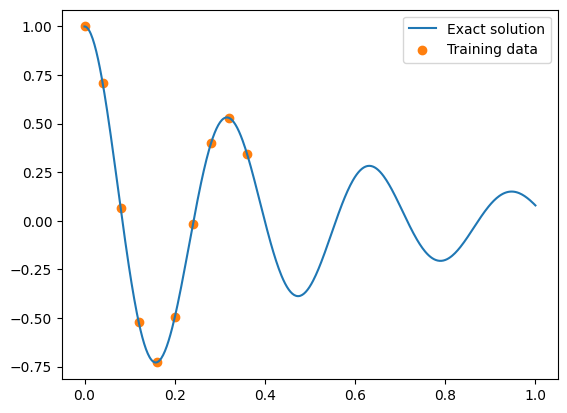

In [ ]:
d, w0 = 2, 20

# get the analytical solution over the full domain
x = torch.linspace(0,1,500).view(-1,1)
y = oscillator(d, w0, x).view(-1,1)
print(x.shape, y.shape)

# slice out a small number of points from the LHS of the domain
x_data = x[0:200:20]
y_data = y[0:200:20]
print(x_data.shape, y_data.shape)

plt.figure()
plt.plot(x, y, label="Exact solution")
plt.scatter(x_data, y_data, color="tab:orange", label="Training data")
plt.legend()
plt.show()

## Normal neural network

> Next, we train a standard neural network (fully connected network) to fit these training points.

>We find that the network is able to fit the solution very closely in the vicinity of the training points, but does not learn an accurate solution outside of them.

In [ ]:
def plot_result(x,y,x_data,y_data,yh,xp=None):
    "Pretty plot training results"
    plt.figure(figsize=(8,4))
    plt.plot(x,y, color="grey", linewidth=2, alpha=0.8, label="Exact solution")
    plt.plot(x,yh, color="tab:blue", linewidth=4, alpha=0.8, label="Neural network prediction")
    plt.scatter(x_data, y_data, s=60, color="tab:orange", alpha=0.4, label='Training data')
    if xp is not None:
        plt.scatter(xp, -0*torch.ones_like(xp), s=60, color="tab:green", alpha=0.4,
                    label='Physics loss training locations')
    l = plt.legend(loc=(1.01,0.34), frameon=False, fontsize="large")
    plt.setp(l.get_texts(), color="k")
    plt.xlim(-0.05, 1.05)
    plt.ylim(-1.1, 1.1)
    plt.text(1.065,0.7,"Training step: %i"%(i+1),fontsize="xx-large",color="k")
    plt.axis("off")



In [ ]:
#creating the plots directory
import os
os.makedirs("plots", exist_ok=True)

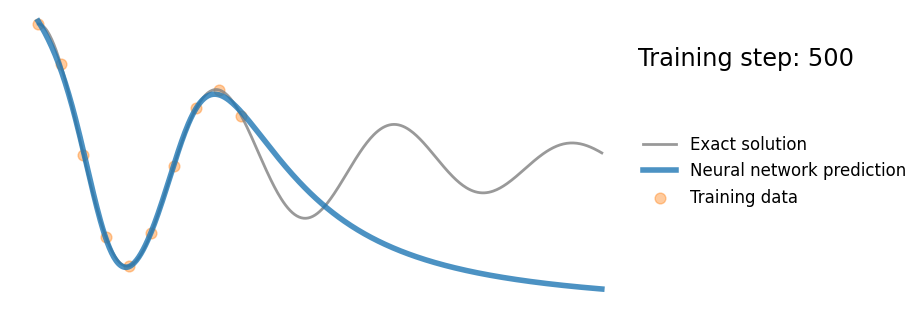

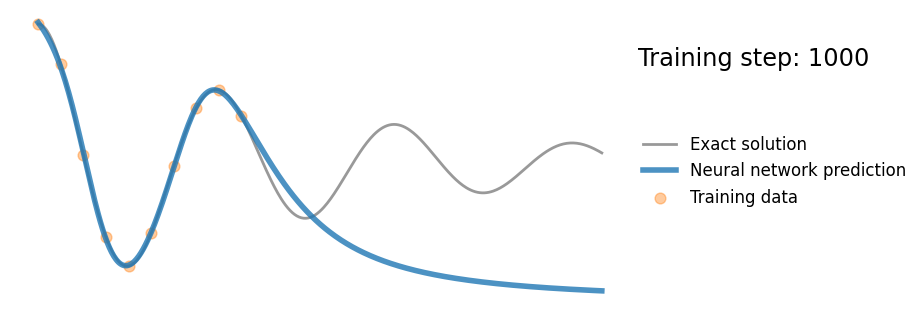

In [ ]:
# train standard neural network to fit training data
torch.manual_seed(123)
model = FCN(1,1,32,3)
optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)
files = []
for i in range(1000):
    optimizer.zero_grad()
    yh = model(x_data)
    loss = torch.mean((yh-y_data)**2)# use mean squared error
    loss.backward()
    optimizer.step()


    # plot the result as training progresses
    if (i+1) % 10 == 0:

        yh = model(x).detach()

        plot_result(x,y,x_data,y_data,yh)

        file = "plots/nn_%.8i.png"%(i+1)
        plt.savefig(file, bbox_inches='tight', pad_inches=0.1, dpi=100, facecolor="white")
        files.append(file)

        if (i+1) % 500 == 0: plt.show()
        else: plt.close("all")

save_gif_PIL("nn.gif", files, fps=20, loop=0)

## PINN

> Finally, we add the underlying differential equation ("physics loss") to the loss function.

The physics loss aims to ensure that the learned solution is consistent with the underlying differential equation. This is done by penalising the residual of the differential equation over a set of locations sampled from the domain.

Here we evaluate the physics loss at 30 points uniformly spaced over the problem domain $([0,1])$. We can calculate the derivatives of the network solution with respect to its input variable at these points using `pytorch`'s autodifferentiation features, and can then easily compute the residual of the differential equation using these quantities.

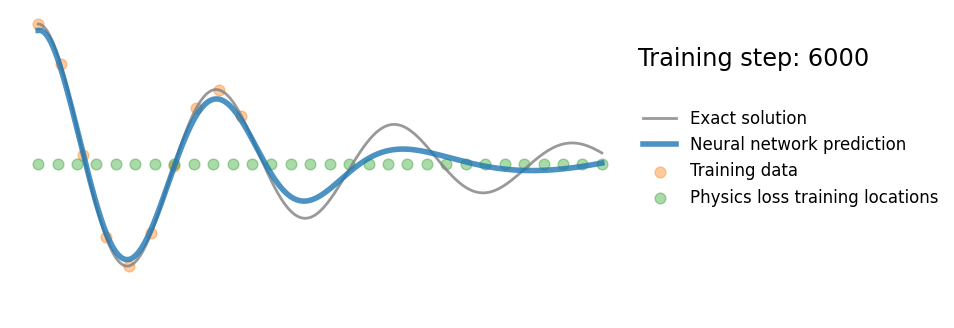

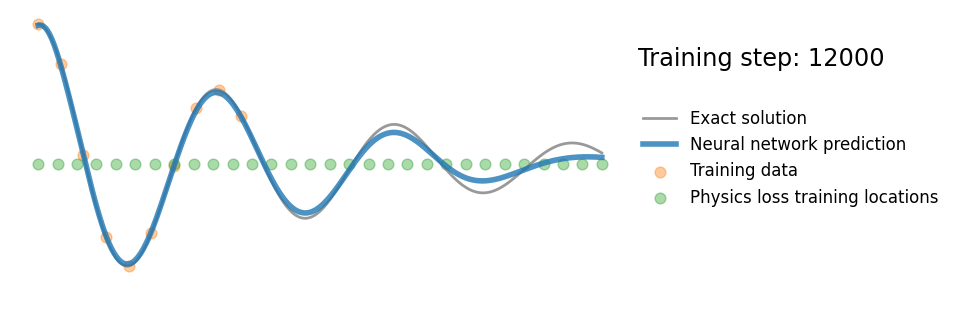

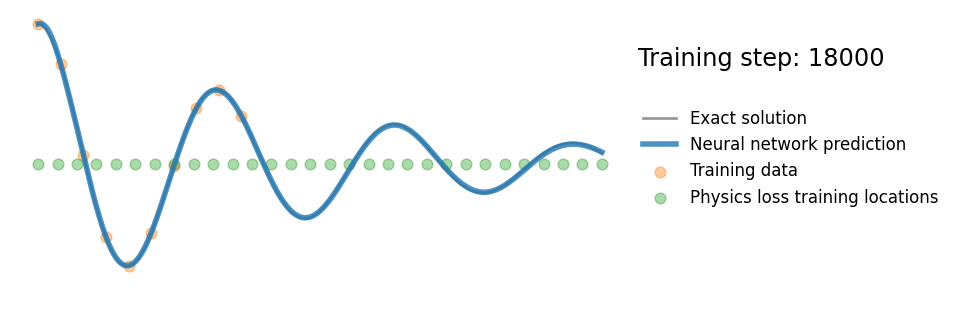

In [ ]:
x_physics = torch.linspace(0,1,30).view(-1,1).requires_grad_(True)# sample locations over the problem domain
mu, k = 2*d, w0**2

torch.manual_seed(123)
model = FCN(1,1,32,3)
optimizer = torch.optim.Adam(model.parameters(),lr=1e-4)
files = []
for i in range(20000):
    optimizer.zero_grad()

    # compute the "data loss"
    yh = model(x_data)
    loss1 = torch.mean((yh-y_data)**2)# use mean squared error

    # compute the "physics loss"
    yhp = model(x_physics)
    dx  = torch.autograd.grad(yhp, x_physics, torch.ones_like(yhp), create_graph=True)[0]# computes dy/dx
    dx2 = torch.autograd.grad(dx,  x_physics, torch.ones_like(dx),  create_graph=True)[0]# computes d^2y/dx^2
    physics = dx2 + mu*dx + k*yhp# computes the residual of the 1D harmonic oscillator differential equation
    loss2 = (1e-4)*torch.mean(physics**2)

    # backpropagate joint loss
    loss = loss1 + loss2# add two loss terms together
    loss.backward()
    optimizer.step()


    # plot the result as training progresses
    if (i+1) % 150 == 0:

        yh = model(x).detach()
        xp = x_physics.detach()

        plot_result(x,y,x_data,y_data,yh,xp)

        file = "plots/pinn_%.8i.png"%(i+1)
        plt.savefig(file, bbox_inches='tight', pad_inches=0.1, dpi=100, facecolor="white")
        files.append(file)

        if (i+1) % 6000 == 0: plt.show()
        else: plt.close("all")

save_gif_PIL("pinn.gif", files, fps=20, loop=0)

## EXERCISES- PROGRAMMING

Task 1 — Frequency Sweep


Train the PINN for each value of ω₀ ∈ {1, 5, 10, 15, 20}.

For each ω₀, record:

Final training loss
Final L² error between predicted x(t) and exact solution
Produce two plots:

Final L² error vs ω₀ (bar chart or line plot)
Worst-case: plot predicted vs exact x(t) for the ω₀ that performs worst



Training PINN for w0 = 5
  Final Loss: 0.000823, L2 Error: 0.000984

Training PINN for w0 = 10
  Final Loss: 0.000189, L2 Error: 0.000197

Training PINN for w0 = 15
  Final Loss: 0.001580, L2 Error: 0.000641

Training PINN for w0 = 20
  Final Loss: 0.029428, L2 Error: 0.017121


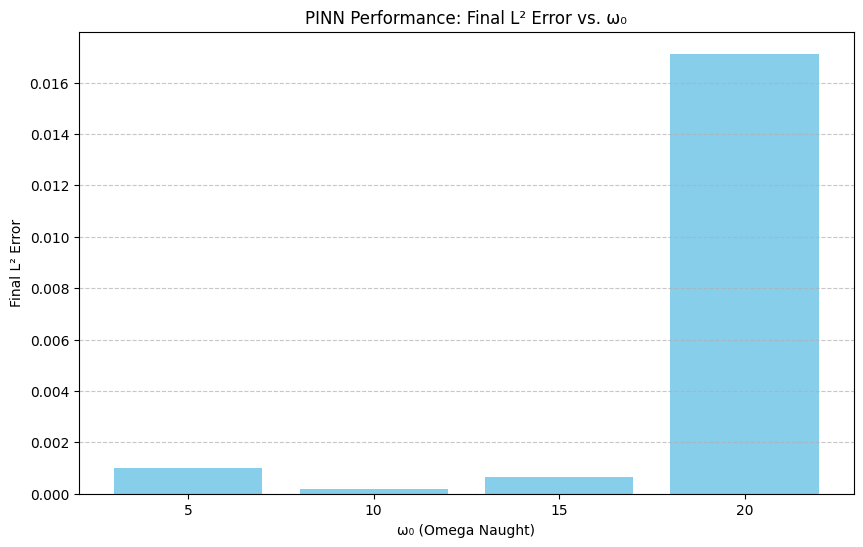

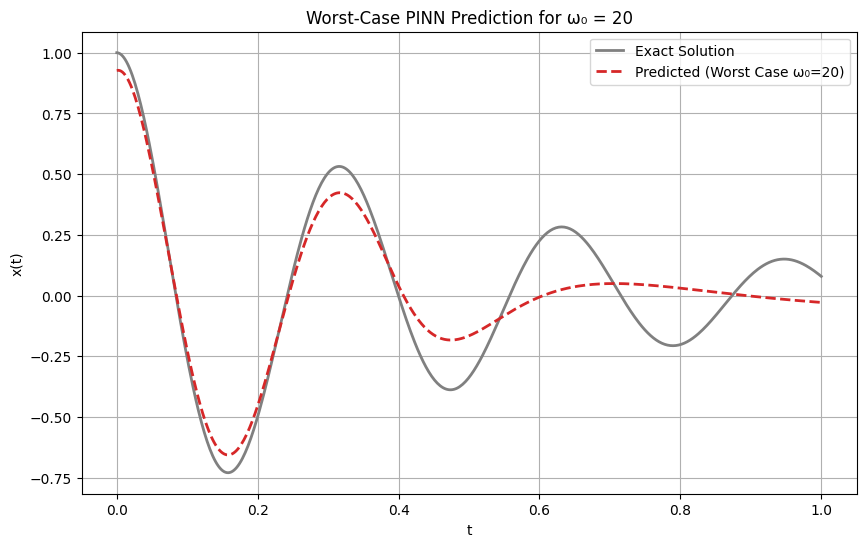

In [ ]:
w0_values = [5, 10, 15, 20]
d = 2 # delta, as defined previously

final_losses = []
l2_errors = []

worst_w0 = None
worst_l2_error = -1
worst_y_pred = None
worst_y_exact = None

# Number of training epochs
#(with the value of 20000, no significant results were visible- or atleast the spectral bias wasn't very clearly demonstrated)
num_epochs = 5000

for current_w0 in w0_values:
    print(f"\nTraining PINN for w0 = {current_w0}")

    # Recalculate exact solution and training data for current w0
    x = torch.linspace(0,1,500).view(-1,1)
    y_exact = oscillator(d, current_w0, x).view(-1,1)

    x_data = x[0:200:20]
    y_data = y_exact[0:200:20]

    # Define mu and k for the current w0
    mu = 2 * d
    k = current_w0**2

    # Physics training points
    x_physics = torch.linspace(0,1,30).view(-1,1).requires_grad_(True)

    # Initialize a new model and optimizer for each w0
    torch.manual_seed(123)
    model = FCN(1,1,32,3)
    optimizer = torch.optim.Adam(model.parameters(),lr=1e-4)

    # PINN training loop
    for i in range(num_epochs):
        optimizer.zero_grad()

        # Data loss
        yh_data = model(x_data)
        loss1 = torch.mean((yh_data-y_data)**2)

        # Physics loss
        yhp = model(x_physics)
        dx  = torch.autograd.grad(yhp, x_physics, torch.ones_like(yhp), create_graph=True)[0]
        dx2 = torch.autograd.grad(dx,  x_physics, torch.ones_like(dx),  create_graph=True)[0]
        physics = dx2 + mu*dx + k*yhp
        loss2 = (1e-4)*torch.mean(physics**2)

        # Total loss
        loss = loss1 + loss2
        loss.backward()
        optimizer.step()

    final_losses.append(loss.item())

    # Calculate L2 error
    yh_final = model(x).detach()
    l2_error = torch.mean((yh_final - y_exact)**2).item()
    l2_errors.append(l2_error)

    print(f"  Final Loss: {loss.item():.6f}, L2 Error: {l2_error:.6f}")

    # Check for worst-case performance
    if l2_error > worst_l2_error:
        worst_l2_error = l2_error
        worst_w0 = current_w0
        worst_y_pred = yh_final
        worst_y_exact = y_exact

# --- Plotting Results ---

# Plot 1: Final L2 error vs omega_0
plt.figure(figsize=(10, 6))
plt.bar([str(w) for w in w0_values], l2_errors, color='skyblue')
plt.xlabel('ω₀ (Omega Naught)')
plt.ylabel('Final L² Error')
plt.title('PINN Performance: Final L² Error vs. ω₀')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Plot 2: Worst-case predicted vs exact x(t)
if worst_w0 is not None:
    plt.figure(figsize=(10, 6))
    plt.plot(x.numpy(), worst_y_exact.numpy(), color='grey', linewidth=2, label='Exact Solution')
    plt.plot(x.numpy(), worst_y_pred.numpy(), color='tab:red', linewidth=2, linestyle='--', label=f'Predicted (Worst Case ω₀={worst_w0})')
    plt.xlabel('t')
    plt.ylabel('x(t)')
    plt.title(f'Worst-Case PINN Prediction for ω₀ = {worst_w0}')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No worst-case found. Something went wrong or w0_values was empty.")

## SECOND EXERCISE:

1. Spectral bias is the neural network's inability to capture functions with a highly oscillating nature, or in other words, the bias of the optimisation performed neural networks towards the lower frequencies of the function. Hence, if the function is highly oscillating in nature, the neural network manages to captures its steady part (the mean about which it oscillates, but not the waveform itself). This is evident in this example because as we increase w, the frequency of the actual function that the NN is trying to capture increases. And as w increases, the error also increases. Mathematically, this is because when the spectral decomposition of the error is seen, the coefficients of the eigen vectors have the corresponding eigen values with a negative sign in the exponential term. The larger eigen values correspond to the faster learning rate.

1. Can fix it by introducing a non-linear transformation using a trigonometric function (map x to sin(wx)). This helps overcoming the aforementioned problem of the underfitting, because of the inherent oscillatory nature (and the fact that the derivatives repeat) of these trigonometric functions.  